In [40]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
from tensorflow import keras

In [41]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, cache_dir=".", untar=True)

In [42]:
data_dir

'.\\datasets\\flower_photos'

In [43]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [44]:
image_count = len(list(data_dir.rglob("*/*.jpg")))
image_count

3670

In [45]:
roses = list(data_dir.rglob("roses/*"))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

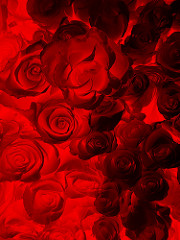

In [46]:
PIL.Image.open(str(roses[4]))

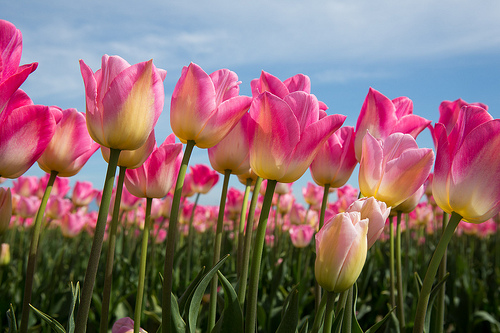

In [47]:
tulips = list(data_dir.rglob("tulips/*"))
PIL.Image.open(str(tulips[3]))

In [48]:
flower_images_dict = {
    "roses" : list(data_dir.rglob("roses/*")),
    "daisy" : list(data_dir.rglob("daisy/*")),
    "dandelion" : list(data_dir.rglob("dandelion/*")),
    "sunflowers" : list(data_dir.rglob("sunflowers/*")),
    "tulips" : list(data_dir.rglob("tulips/*"))
}

In [49]:
flowers_labels_dict = {
    "roses" : 0,
    "daisy" : 1,
    "dandelion" : 2,
    "sunflowers" : 3,
    "tulips" : 4
}

In [50]:
str(flower_images_dict["roses"][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [51]:
img = cv2.imread(str(flower_images_dict["roses"][0]))
img.shape

(240, 179, 3)

**To change the sizes of the image**

In [52]:
cv2.resize(img, (180, 180)).shape

(180, 180, 3)

In [53]:
X, y = [], []
for flower_name, images in flower_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (180, 180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [55]:
X = np.array(X)
y = np.array(y)

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [58]:
X_train = X_train/255
X_test = X_test/255

In [61]:
model = keras.Sequential([
    keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(80, activation="relu"),
    keras.layers.Dense(5, activation="sigmoid")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 402ms/step - accuracy: 0.4110 - loss: 1.3525
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 332ms/step - accuracy: 0.5741 - loss: 1.0491
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 312ms/step - accuracy: 0.6708 - loss: 0.8720
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.7802 - loss: 0.6271
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - accuracy: 0.8485 - loss: 0.4334
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - accuracy: 0.9070 - loss: 0.2726
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.9506 - loss: 0.1444
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 252ms/step - accuracy: 0.9688 - loss: 0.0831
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 324ms/step - accuracy: 0.9778 - loss: 0.0489
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.9767 - loss: 0.0254


In [62]:
model.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6068 - loss: 2.2727


[2.2727267742156982, 0.6067538261413574]

**Here we can see the model is overfitted and it is showing lower accuracy on the testing data**

In [77]:
data_augmentation = keras.Sequential([
    keras.layers.RandomZoom(0.43),
    keras.layers.RandomRotation(0.34),
    keras.layers.RandomFlip("horizontal", input_shape=(180, 180, 3))
])

d:\Deep Learning\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


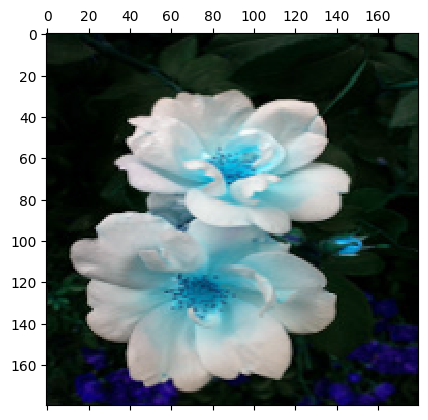

In [78]:
plt.matshow(X[0])

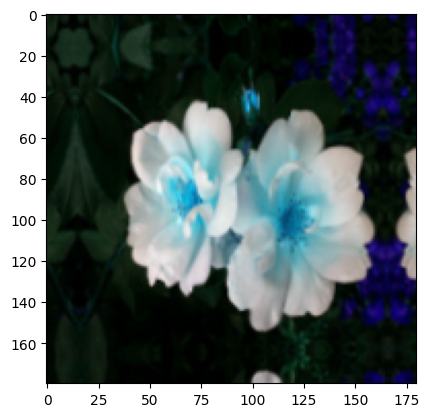

In [79]:
plt.imshow(data_augmentation(X[:1])[0].numpy().astype("uint8"))

**Now training again with the data augmentation**

In [82]:
model = keras.Sequential([
    data_augmentation,
    keras.layers.Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.2),
    keras.layers.Flatten(),
    keras.layers.Dense(80, activation="relu"),
    keras.layers.Dense(5, activation="sigmoid")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=25)

Epoch 1/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 532ms/step - accuracy: 0.4157 - loss: 1.3641
Epoch 2/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step - accuracy: 0.5345 - loss: 1.1120
Epoch 3/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 461ms/step - accuracy: 0.5956 - loss: 1.0151
Epoch 4/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 314ms/step - accuracy: 0.6254 - loss: 0.9699
Epoch 5/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 274ms/step - accuracy: 0.6257 - loss: 0.9363
Epoch 6/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.6512 - loss: 0.9106
Epoch 7/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 279ms/step - accuracy: 0.6570 - loss: 0.8537
Epoch 8/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.6650 - loss: 0.8454
Epoch 9/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 38s 442ms/step - accuracy: 0.6795 - loss: 0.8336
Epoch 10/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 308ms/step - accuracy: 0.6730 - loss: 0.8346
Epoch 11/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 296ms/step - accuracy: 0.6868 - loss: 0.7978
Epoch 12/25
86/86 ━━━━━━━━━━━━━━━━━━━━ 28

In [83]:
model.evaluate(X_test, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6993 - loss: 0.7697


[0.7697045803070068, 0.6993464231491089]

**Hence we can see that model is performing quite better after using the data augmentation in it**